# 1. Sparkline com dados do OECD

Primeiro obtemos os dados pela API do OECD

In [1]:
import pandas as pd
import requests

url = "https://sdmx.oecd.org/public/rest/data/OECD.ELS.HD,DSD_SHA@DF_SHA,/.A.EXP_HEALTH.PT_B1GQ._T.._T.._T...?startPeriod=2000&endPeriod=2023&&dimensionAtObservation=AllDimensions&format=csvfilewithlabels"

print("Extraindo dados da OCDE (2000-2023)...")
headers = {"Accept": "text/csv"}
response = requests.get(url, headers=headers)

if response.status_code == 200:
    filename_raw = "oecd_health_spending_2000_2023.csv"

    with open(filename_raw, "wb") as f:
        f.write(response.content)

    df = pd.read_csv(filename_raw)
    print("Download concluído com sucesso!")
    print(f"Colunas disponíveis: {list(df.columns)}")

    df_wide = df.pivot_table(index="Reference area", columns="TIME_PERIOD", values="OBS_VALUE", aggfunc="first")

    df_wide = df_wide.reindex(sorted(df_wide.columns), axis=1)

    df_wide = df_wide.sort_index()

    filename_wide = "oecd_health_spending.csv"
    df_wide.to_csv(filename_wide)
    print(f"\nArquivo pivotado salvo em: {filename_wide}")

else:
    print(f"Erro na requisição à API: Código {response.status_code}")

Extraindo dados da OCDE (2000-2023)...
Download concluído com sucesso!
Colunas disponíveis: ['STRUCTURE', 'STRUCTURE_ID', 'STRUCTURE_NAME', 'ACTION', 'REF_AREA', 'Reference area', 'FREQ', 'Frequency of observation', 'MEASURE', 'Measure', 'UNIT_MEASURE', 'Unit of measure', 'FINANCING_SCHEME', 'Financing scheme', 'FINANCING_SCHEME_REV', 'Revenues of financing schemes', 'FUNCTION', 'Health function', 'MODE_PROVISION', 'Mode of provision', 'PROVIDER', 'Healthcare provider', 'FACTOR_PROVISION', 'Factor of provision', 'ASSET_TYPE', 'Asset type', 'PRICE_BASE', 'Price base', 'TIME_PERIOD', 'Time period', 'OBS_VALUE', 'Observation value', 'BASE_PER', 'Base period', 'CURRENCY', 'Currency', 'OBS_STATUS', 'Observation status', 'OBS_STATUS2', 'Observation status 2', 'OBS_STATUS3', 'Observation status 3', 'UNIT_MULT', 'Unit multiplier', 'DECIMALS', 'Decimals']

Arquivo pivotado salvo em: oecd_health_spending.csv


In [36]:
df_wide

TIME_PERIOD,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
Reference area,,,,,,,,,,,,,,,,,,,,,
Albania,5.771,5.726,5.455,5.718,5.717,5.588,5.475,5.692,5.352,5.688,...,6.402,6.417,6.658,6.460,6.572,6.781,7.465,7.358,7.536,7.069
Argentina,8.220,8.270,7.332,6.927,7.095,7.734,7.709,7.862,8.241,9.569,...,9.798,10.274,10.054,10.272,10.315,10.123,10.739,11.061,10.476,10.337
Australia,7.574,7.661,7.859,7.864,8.070,7.951,7.957,8.034,8.221,8.515,...,9.788,10.097,10.060,10.093,10.082,10.262,10.743,10.561,9.957,10.362
Austria,9.389,9.452,9.591,9.698,9.815,9.718,9.641,9.605,9.834,10.312,...,10.512,10.517,10.517,10.571,10.516,10.625,11.413,12.185,11.191,11.176
Belgium,7.999,8.150,8.318,9.165,9.328,9.222,9.128,9.135,9.595,10.539,...,10.616,10.877,10.884,10.927,10.984,10.847,11.453,11.280,10.801,10.793
Bosnia and Herzegovina,7.963,7.573,7.399,8.281,9.063,8.820,8.884,9.255,9.486,9.015,...,9.471,9.241,9.139,8.818,8.761,8.925,9.703,9.555,8.716,8.922
Brazil,8.335,8.550,8.697,8.189,8.125,8.035,8.250,8.202,8.011,8.395,...,8.396,8.909,9.169,9.474,9.465,9.614,9.623,9.636,9.387,NaN
Bulgaria,NaN,NaN,NaN,7.200,6.891,6.890,6.525,6.157,6.283,6.596,...,7.683,7.394,7.460,7.496,7.358,7.131,8.448,8.585,7.639,7.934
Canada,8.248,8.625,8.857,9.011,9.066,9.035,9.346,9.449,9.609,10.722,...,10.268,10.757,11.045,10.935,10.900,11.023,12.991,12.366,11.020,11.389


Agora podemos usar os dados acima para construir o Sparkline. Os países selecionados foram os mesmos dos mostrados no slide que continha o gráfico original, com a adição de um país, o Brasil.

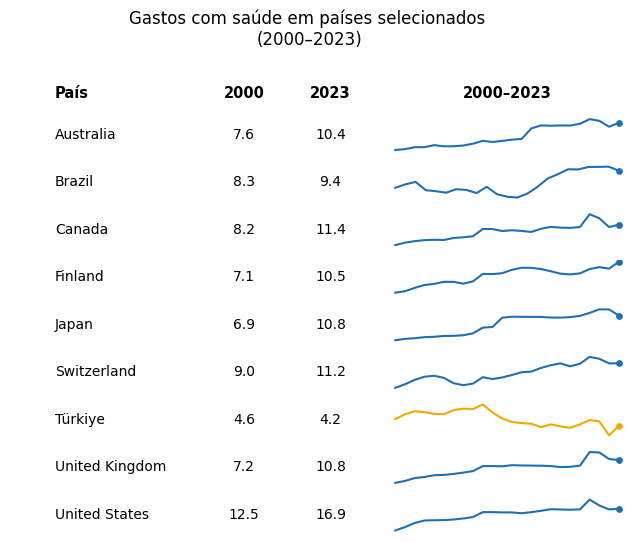

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

df = pd.read_csv("oecd_health_spending.csv", index_col=0)

df.columns = df.columns.astype(int)

paises = ["Australia", "Brazil", "Canada", "Finland", "Japan", "Switzerland", "Türkiye", "United Kingdom", "United States"]

df_sel = df.loc[paises]

ano_inicial = 2000
ano_final = 2023

variacao = df_sel[ano_final] - df_sel[ano_inicial]
paises_em_queda = variacao[variacao < 0]
pais_destaque = paises_em_queda.idxmin() if len(paises_em_queda) > 0 else None

cor_normal = "#1f6fb2"
cor_destaque = "#f2a900"

num_paises = len(df_sel)
n_linha = num_paises + 1

fig = plt.figure(figsize=(8, (0.5 * num_paises) + 1.5))
gs = gridspec.GridSpec(n_linha, 4, width_ratios=[2.2, 0.8, 0.8, 3], wspace=0.15, hspace=0.4)

fig.suptitle(f"Gastos com saúde em países selecionados \n({ano_inicial}\u2013{ano_final})")

headers = ["País", str(ano_inicial), str(ano_final), f"{ano_inicial}\u2013{ano_final}"]
aligns = ["left", "center", "center", "center"]
positions = [0.25, 0.5, 0.5, 0.5]

for col_idx, (text, align, pos) in enumerate(zip(headers, aligns, positions)):
    ax_hdr = fig.add_subplot(gs[0, col_idx])
    ax_hdr.text(pos, 0.3, text, fontsize=10.5, fontweight="bold", ha=align, va="center")
    ax_hdr.axis("off")

for i, pais in enumerate(df_sel.index):
    row_idx = i + 1
    serie = df_sel.loc[pais].dropna()
    cor = cor_destaque if pais == pais_destaque else cor_normal

    ax_nome = fig.add_subplot(gs[row_idx, 0])
    ax_nome.text(0.25, 0.5, pais, va="center", ha="left", fontsize=10)
    ax_nome.axis("off")

    ax_ini = fig.add_subplot(gs[row_idx, 1])
    ax_ini.text(0.5, 0.5, f"{serie.iloc[0]:.1f}", va="center", ha="center", fontsize=10)
    ax_ini.axis("off")

    ax_fim = fig.add_subplot(gs[row_idx, 2])
    ax_fim.text(0.5, 0.5, f"{serie.iloc[-1]:.1f}", va="center", ha="center", fontsize=10)
    ax_fim.axis("off")

    ax_spark = fig.add_subplot(gs[row_idx, 3])
    ax_spark.plot(serie.index, serie.values, color=cor, linewidth=1.5)
    ax_spark.scatter(serie.index[-1], serie.iloc[-1], color=cor, s=15, zorder=3)
    ax_spark.axis("off")

plt.show()

Turquia ainda é o país de destaque, sendo o único que mostrou uma queda entre 2000 e 2023. Analisando o avanço do investimento ao longo dos anos, é possível ver que dos 23 anos observados 14 tiveram uma queda no investimento em relação ao ano anterior.

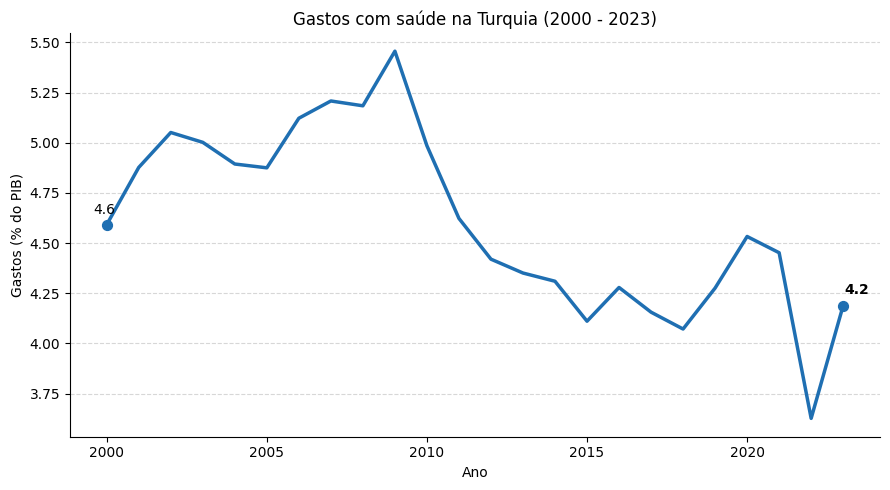

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df_wide = pd.read_csv("oecd_health_spending.csv", index_col=0)

df_wide.columns = df_wide.columns.astype(int)

pais = "Türkiye"
serie_turquia = df_wide.loc[pais].dropna()

ano_inicial = 2000
ano_final = 2023
valor_inicial = serie_turquia.iloc[0]
valor_final = serie_turquia.iloc[-1]

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(serie_turquia.index, serie_turquia.values, color="#1f6fb2", linewidth=2.5, label=pais)

ax.scatter([ano_inicial, ano_final], [valor_inicial, valor_final], color="#1f6fb2", s=50, zorder=4)

ax.annotate(f"{valor_inicial:.1f}", (ano_inicial, valor_inicial), textcoords="offset points", xytext=(-10, 8))

ax.annotate(f"{valor_final:.1f}", (ano_final, valor_final), textcoords="offset points", xytext=(10, 8), ha='center', fontweight='bold', fontsize=10)

ax.set_title(f"Gastos com saúde na Turquia (2000 - 2023)", loc='center')
ax.set_xlabel("Ano", loc='center')
ax.set_ylabel("Gastos (% do PIB)", loc='center')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 2. Ranking dos países no OECD

Seguindo o exemplo do slide apresentado em aula, resolvi usar um bump chart para representar os 10 países com mais gastos em saúde. 

Países que passaram pelo Top 10 em algum ano: 23


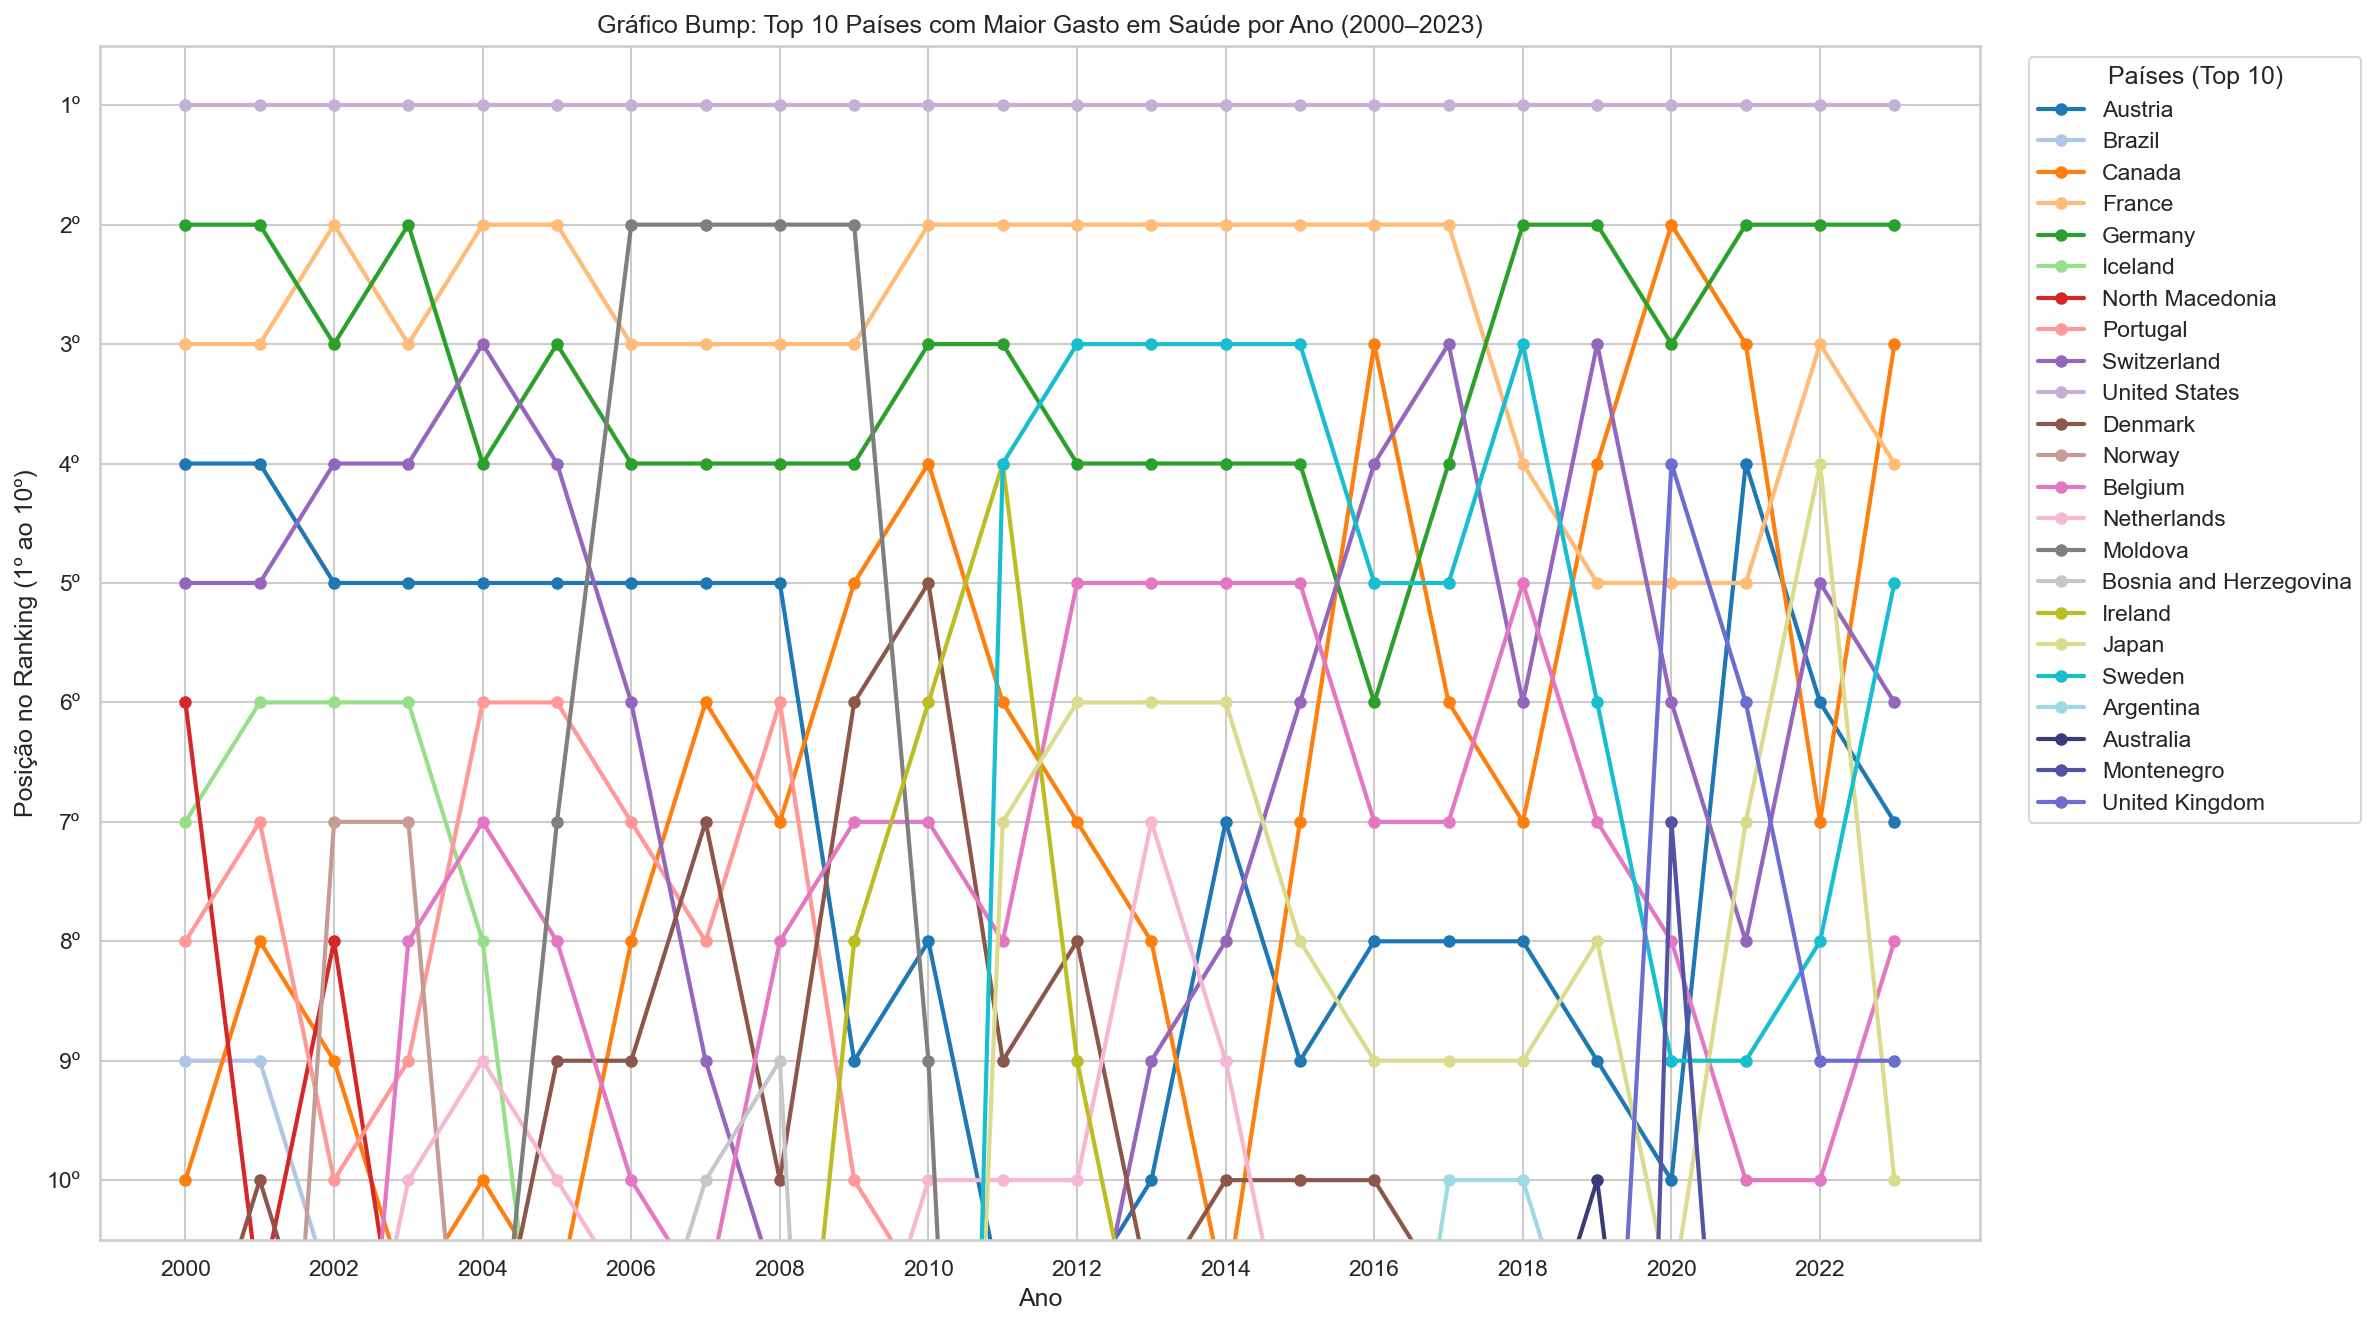

Total de países na base (gráfico de 34 linhas): 59


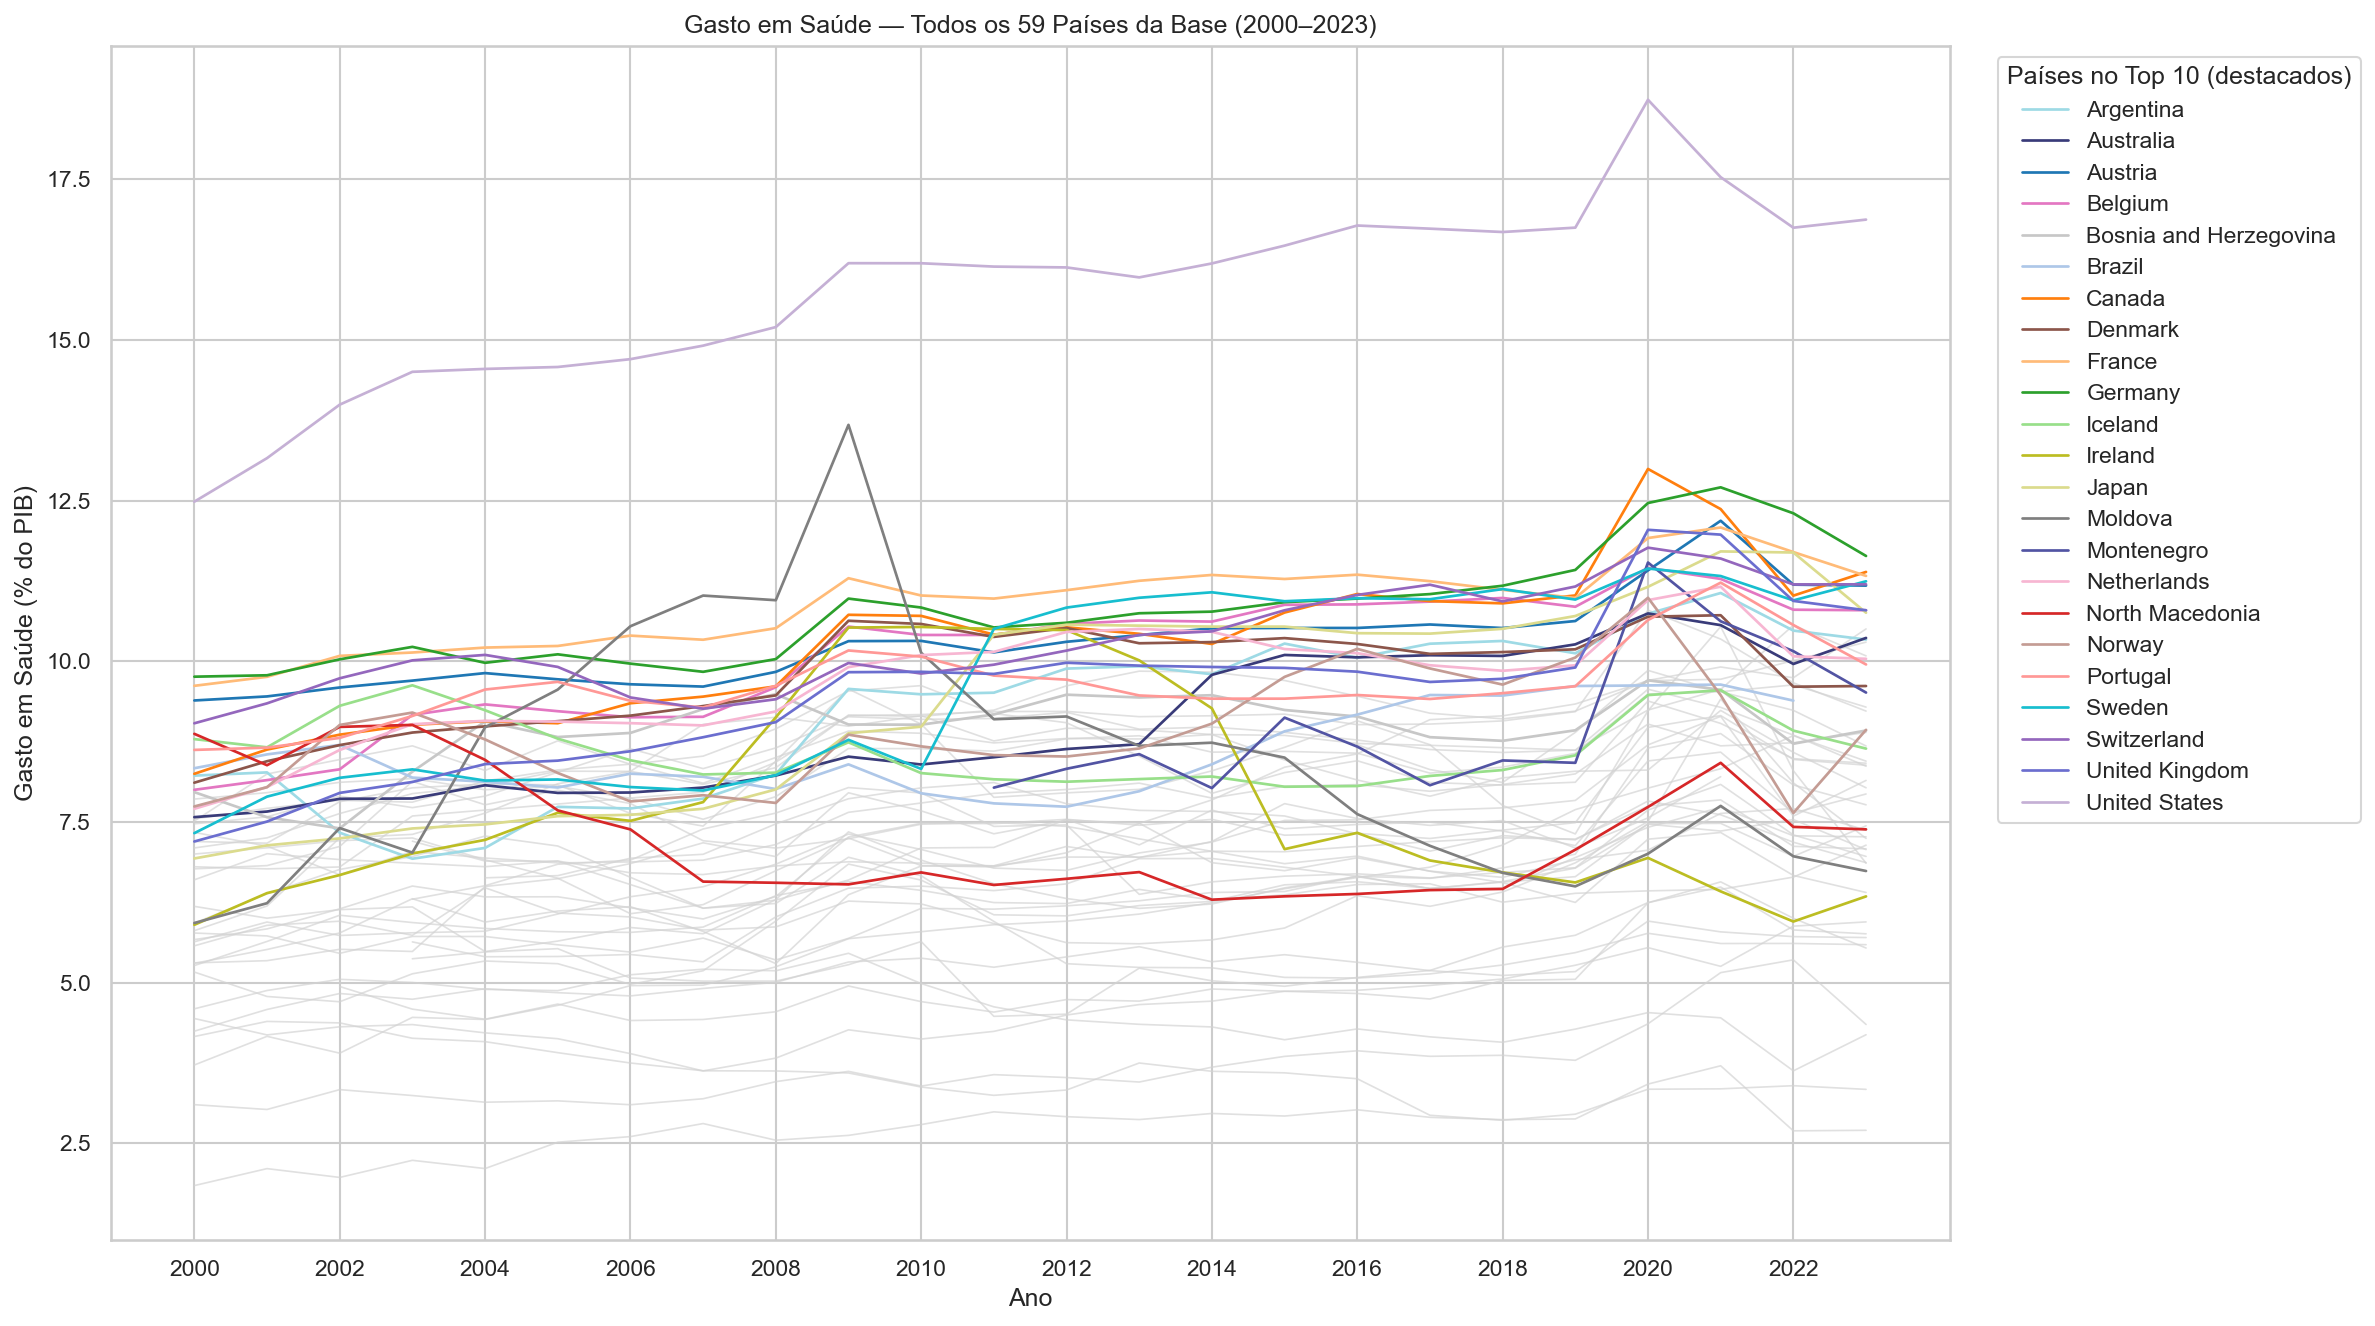

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

df = pd.read_csv('oecd_health_spending.csv')

df_long = df.melt(id_vars=['Reference area'], var_name='Year', value_name='Spending')
df_long['Year'] = df_long['Year'].astype(int)

df_long['Rank'] = df_long.groupby('Year')['Spending'].rank(ascending=False, method='min')

top10_countries = df_long[df_long['Rank'] <= 10]['Reference area'].unique()
n_paises = len(top10_countries)
print(f"Países que passaram pelo Top 10 em algum ano: {n_paises}")

plt.figure(figsize=(16, 9), dpi=150)
sns.set_theme(style="whitegrid")

paleta_base = (list(plt.cm.tab20.colors) + list(plt.cm.tab20b.colors) + list(plt.cm.tab20c.colors))

if n_paises <= len(paleta_base):
    colors = paleta_base[:n_paises]
else:
    colors = [mcolors.hsv_to_rgb((i / n_paises, 0.75, 0.85)) for i in range(n_paises)]

country_color_map = {country: colors[i] for i, country in enumerate(top10_countries)}

for country in top10_countries:
    group = df_long[df_long['Reference area'] == country].sort_values('Year')
    plt.plot(group['Year'], group['Rank'], marker='o', markersize=5, linewidth=2, color=country_color_map[country], label=country)

plt.gca().invert_yaxis()
plt.ylim(10.5, 0.5)
plt.yticks(range(1, 11), [f'{i}º' for i in range(1, 11)])

plt.title('Gráfico Bump: Top 10 Países com Maior Gasto em Saúde por Ano (2000–2023)', loc='center')
plt.xlabel('Ano')
plt.ylabel('Posição no Ranking (1º ao 10º)')
plt.xticks(range(2000, 2024, 2))

plt.legend(title='Países (Top 10)', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

todos_paises = df_long['Reference area'].unique()
n_todos = len(todos_paises)
print(f"Total de países na base (gráfico de 34 linhas): {n_todos}")

plt.figure(figsize=(16, 9), dpi=150)
sns.set_theme(style="whitegrid")

for country in todos_paises:
    group = df_long[df_long['Reference area'] == country].sort_values('Year')
    if country in top10_countries:
        plt.plot(group['Year'], group['Spending'], linewidth=1.3,
                 color=country_color_map[country], zorder=3, label=country)
    else:
        plt.plot(group['Year'], group['Spending'], linewidth=0.8,
                 color="lightgray", alpha=0.7, zorder=1)

plt.title(f'Gasto em Saúde — Todos os {n_todos} Países da Base (2000–2023)', loc='center')
plt.xlabel('Ano')
plt.ylabel('Gasto em Saúde (% do PIB)')
plt.xticks(range(2000, 2024, 2))
plt.legend(title='Países no Top 10 (destacados)', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

O gráfico de linhas fica confuso pela quantidade de linhas se intercalando, já que diversos países no top 10 apresentam custos semelhantes. Este gráfico seria melhor se o objetivo fosse comparar 2 ou mais países. 

# 3. Nascimentos mensais no Brasil

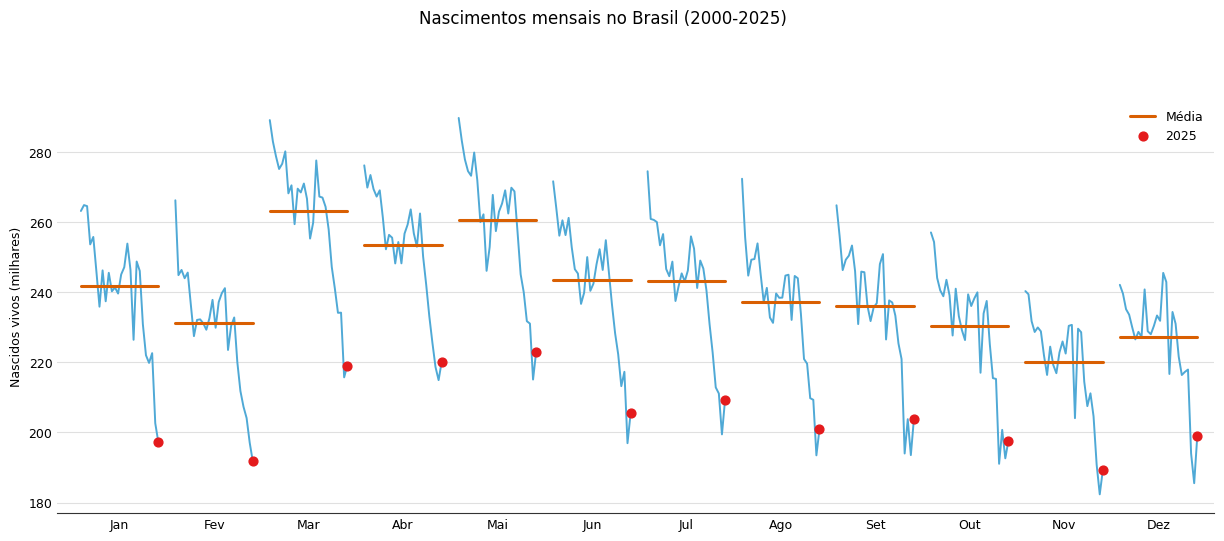

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("sinasc.csv", sep=";", encoding="latin-1", skiprows=3, engine="python")
df = df.rename(columns={df.columns[0]: "mes"})

meses_ordem = ["Janeiro","Fevereiro","Marco","Abril","Maio","Junho", "Julho","Agosto","Setembro","Outubro","Novembro","Dezembro"]
meses_label = ["Jan","Fev","Mar","Abr","Mai","Jun", "Jul","Ago","Set","Out","Nov","Dez"]

df = df[df["mes"].isin(meses_ordem)].copy()
df = df.drop(columns=["Total"], errors="ignore")

for c in df.columns[1:]:
    df[c] = df[c].replace("-", np.nan)
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["mes"] = pd.Categorical(df["mes"], categories=meses_ordem, ordered=True)
df = df.sort_values("mes").set_index("mes")
df.columns = df.columns.astype(int)

ANO_DESTAQUE = 2025

anos_hist = [a for a in sorted(df.columns) if a != ANO_DESTAQUE and df[a].notna().all()]
ANO_INI, ANO_FIM = anos_hist[0], anos_hist[-1]
n_hist = len(anos_hist)

dados_destaque = df[ANO_DESTAQUE].copy() if ANO_DESTAQUE in df.columns else pd.Series(np.nan, index=df.index)
tem_destaque = dados_destaque.notna().any()

df = df / 1000.0
dados_destaque = dados_destaque / 1000.0

n_pos = n_hist + 1

fig, ax = plt.subplots(figsize=(13, 6))

largura_mes = 0.82
cor_hist   = "#4fa9d6"
cor_media  = "#d95f02"
cor_dest   = "#e41a1c"

legenda_media_feita = False
legenda_dest_feita  = False

for i, mes in enumerate(meses_ordem):
    x0 = i * 1.0
    xs_todos = x0 + np.linspace(0, largura_mes, n_pos)
    xs_hist  = xs_todos[:n_hist]       
    x_dest   = xs_todos[-1]              

    serie_hist = df.loc[mes, anos_hist].values

    val_dest = dados_destaque.loc[mes]
    tem_val  = pd.notna(val_dest)

    if tem_val:
        xs_linha  = np.append(xs_hist, x_dest)
        serie_lin = np.append(serie_hist, val_dest)
    else:
        xs_linha  = xs_hist
        serie_lin = serie_hist

    ax.plot(xs_linha, serie_lin, color=cor_hist, linewidth=1.4, solid_capstyle="round", zorder=2)

    media = serie_hist.mean()
    lbl_m = "Média" if not legenda_media_feita else ""
    ax.plot([x0, x0 + largura_mes], [media, media], color=cor_media, linewidth=2.2, zorder=3, solid_capstyle="round", label=lbl_m)
    legenda_media_feita = True

    if tem_val:
        lbl_d = f"{ANO_DESTAQUE}" if not legenda_dest_feita else ""
        ax.scatter(x_dest, val_dest, color=cor_dest, s=40, zorder=5, label=lbl_d)
        legenda_dest_feita = True

# Anotações dos anos nas pontas das linhas
xs_jan = 0 + np.linspace(0, largura_mes, n_pos)
xs_jul = 6 + np.linspace(0, largura_mes, n_pos)

ax.set_xlim(-0.25, 12)
ax.set_xticks([i + largura_mes / 2 for i in range(12)])
ax.set_xticklabels(meses_label, fontsize=9)

ax.spines[["top","right","left"]].set_visible(False)
ax.spines["bottom"].set_color("#333333")
ax.yaxis.grid(True, color="#e0e0e0", linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(axis="y", labelsize=9, length=0)
ax.tick_params(axis="x", length=0)
ax.set_ylabel("Nascidos vivos (milhares)", fontsize=9)

nota_dest = f"; pontos: {ANO_DESTAQUE}" if tem_destaque else ""

fig.suptitle("Nascimentos mensais no Brasil (2000-2025)")

ax.legend(loc="upper right", frameon=False, fontsize=9)
plt.subplots_adjust(top=0.83, bottom=0.14, left=0.08, right=0.97)

plt.show()

# 4. Série composta

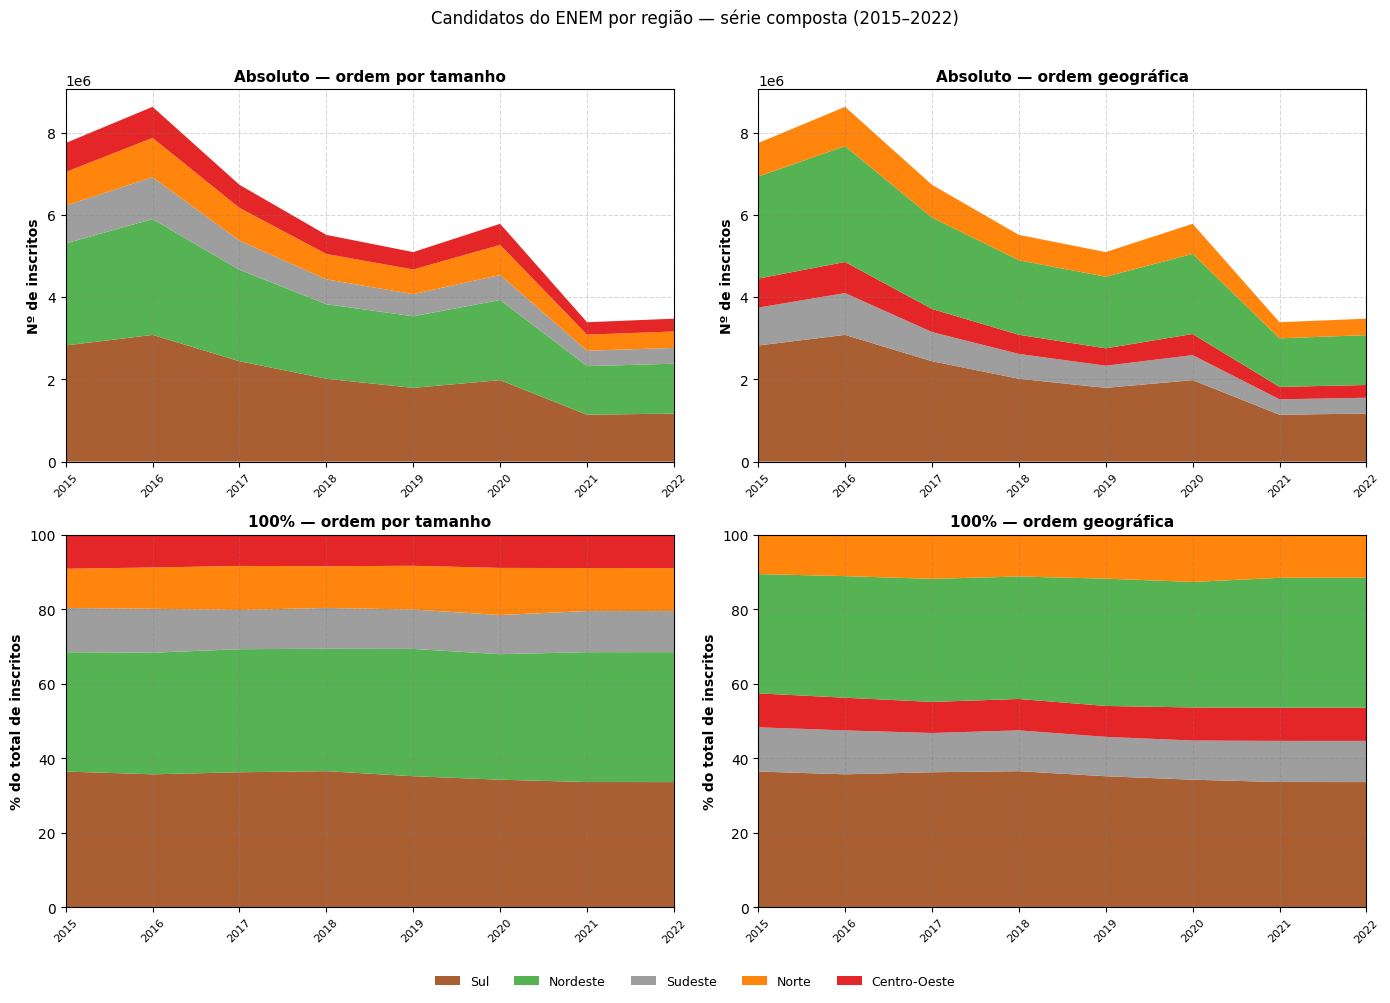

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Dados_Enem.csv", thousands=".")
regioes = ["Centro-Oeste", "Nordeste", "Norte", "Sul", "Sudeste"]
anos = [int(c) for c in df.columns if c != "Região"]

df_regioes = df[df["Região"].isin(regioes)].set_index("Região")
df_regioes.columns = anos
df_regioes = df_regioes.astype(float)

ordem_tamanho = df_regioes[anos[0]].sort_values(ascending=False).index.tolist()

# Ordem geográfica: Norte -> Sul, pela latitude aproximada do centro de cada região
ordem_geografica = ["Sul", "Sudeste", "Centro-Oeste", "Nordeste", "Norte"]

cores_vibrantes = plt.cm.Set1(np.linspace(0, 1, len(regioes)))
cor_regiao = dict(zip(regioes, cores_vibrantes))

def plot_area_empilhada(ax, ordem, percentual, titulo):
    dados = df_regioes.loc[ordem]
    if percentual:
        dados = dados.div(dados.sum(axis=0), axis=1) * 100

    ax.stackplot(anos, dados.values, labels=ordem, colors=[cor_regiao[r] for r in ordem], alpha=0.95)
    ax.set_title(titulo, fontsize=11, fontweight="bold")
    ax.set_xlim(min(anos), max(anos))
    ax.set_xticks(anos)
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.grid(True, linestyle="--", alpha=0.3, color="gray")

    if percentual:
        ax.set_ylim(0, 100)
        ax.set_ylabel("% do total de inscritos", fontweight="bold")
    else:
        ax.set_ylabel("Nº de inscritos", fontweight="bold")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plot_area_empilhada(axes[0, 0], ordem_tamanho, percentual=False, titulo="Absoluto — ordem por tamanho")
plot_area_empilhada(axes[0, 1], ordem_geografica, percentual=False, titulo="Absoluto — ordem geográfica")
plot_area_empilhada(axes[1, 0], ordem_tamanho, percentual=True, titulo="100% — ordem por tamanho")
plot_area_empilhada(axes[1, 1], ordem_geografica, percentual=True, titulo="100% — ordem geográfica")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=5, frameon=False, bbox_to_anchor=(0.5, -0.01), fontsize=9)

fig.suptitle("Candidatos do ENEM por região — série composta (2015–2022)")

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()